# Soft sensor de `% Silica Concentrate` a partir de sensores de proceso

**Objetivo:** estimar una variable de calidad que se mide en laboratorio
(lenta, escasa) usando unicamente sensores de proceso (rapidos, abundantes).
Es el escenario tipico de "poco dato de laboratorio, muchos datos de sensor".

**Soft sensor puro:** en inferencia **no** se usa ningun valor de laboratorio,
ni el actual ni el anterior. Solo entran sensores de proceso. Esto es lo que
permite estimar la calidad de forma continua entre analiticas -- y es tambien
el test honesto de si los sensores contienen realmente informacion sobre la
calidad.

> **Diferencia con `main.ipynb`:** aquel notebook predice `y[t+1h]` partiendo
> del valor de laboratorio actual `y[t]` (persistencia + correccion). Depende
> de recibir una analitica cada hora, así que *extiende* el laboratorio una
> hora, no lo sustituye. Aqui se prohibe expresamente usar `y`, de modo que el
> modelo tiene que explicar la calidad desde el proceso.

**El baseline correcto cambia.** Sin valor de laboratorio no existe la
persistencia, así que el punto de comparacion honesto es **predecir la media
del entrenamiento**. Un soft sensor solo es util si mejora claramente eso.

Estructura del notebook: carga -> diagnostico de senal (¿hay algo que
aprender?) -> modelo -> evaluacion honesta -> analisis de que escala temporal
es realmente predecible.

In [11]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Carga y agregacion horaria

In [12]:
filepath = '../Datasets/MiningProcess_Flotation_Plant_Database.csv'
TARGET = '% Silica Concentrate'

raw = pd.read_csv(filepath, decimal=',')
raw['date'] = pd.to_datetime(raw['date'])

# Columnas de laboratorio: se miden una vez por hora y en el CSV crudo aparecen
# repetidas en las ~180 filas de 20s de esa hora.
LAB_COLS = ['% Iron Feed', '% Silica Feed', '% Iron Concentrate', '% Silica Concentrate']
SENSOR_COLS = [c for c in raw.columns if c not in ['date'] + LAB_COLS]

agg = {c: 'mean' for c in SENSOR_COLS}
agg.update({c: 'first' for c in LAB_COLS})
df = raw.groupby('date', as_index=True).agg(agg).sort_index()

full_range = pd.date_range(df.index.min(), df.index.max(), freq='h')
df = df.reindex(full_range)
for c in df.columns:
    if df[c].isna().any():
        df[c] = df[c].interpolate(method='linear', limit_direction='both')

# Periodo de arranque de la campana (varias columnas con varianza 0): se descarta.
STARTUP_END = pd.Timestamp('2017-03-29 11:01:47.998')
df = df.loc[df.index > STARTUP_END].copy()

print(f"Horas: {len(df)}  |  rango: {df.index.min()} -> {df.index.max()}")
print(f"Sensores de proceso disponibles: {len(SENSOR_COLS)}")

Horas: 3948  |  rango: 2017-03-29 12:00:00 -> 2017-09-09 23:00:00
Sensores de proceso disponibles: 19


## Que se puede usar y que no

La regla del soft sensor puro: **entra solo lo que un sensor da en continuo**.

- `% Silica Concentrate` es el target -- no puede ser feature, ni el actual ni
  retardado. Usar `y[t-1]` convertiria esto en un modelo de persistencia
  disfrazado, que es justo lo que no queremos evaluar aqui.
- `% Iron Concentrate`, `% Iron Feed`, `% Silica Feed` son **medidas de
  laboratorio**, no sensores. Aunque `% Iron Concentrate` correlaciona muy
  fuerte con el target (-0.80), no estaria disponible en continuo, así que
  usarlo daria un resultado imposible de reproducir en planta.

In [13]:
# Todo lo que es laboratorio queda prohibido como feature.
FORBIDDEN = LAB_COLS
FEATURES = [c for c in df.columns if c not in FORBIDDEN]

assert TARGET not in FEATURES, "El target no puede ser feature"
assert not any(c in FEATURES for c in LAB_COLS), "Ninguna medida de laboratorio puede ser feature"

print(f"Features permitidas ({len(FEATURES)}):")
for c in FEATURES:
    print(f"  - {c}")
print(f"\nProhibidas (laboratorio): {FORBIDDEN}")

Features permitidas (19):
  - Starch Flow
  - Amina Flow
  - Ore Pulp Flow
  - Ore Pulp pH
  - Ore Pulp Density
  - Flotation Column 01 Air Flow
  - Flotation Column 02 Air Flow
  - Flotation Column 03 Air Flow
  - Flotation Column 04 Air Flow
  - Flotation Column 05 Air Flow
  - Flotation Column 06 Air Flow
  - Flotation Column 07 Air Flow
  - Flotation Column 01 Level
  - Flotation Column 02 Level
  - Flotation Column 03 Level
  - Flotation Column 04 Level
  - Flotation Column 05 Level
  - Flotation Column 06 Level
  - Flotation Column 07 Level

Prohibidas (laboratorio): ['% Iron Feed', '% Silica Feed', '% Iron Concentrate', '% Silica Concentrate']


## Split cronologico

Train / val / test = 70 / 15 / 15, siempre en orden temporal. Nunca aleatorio:
con series temporales un split aleatorio deja horas contiguas a ambos lados y
el modelo "adivina" por vecindad, no por proceso.

Todo lo que se ajuste (escalados, umbrales, estadisticos) se calcula **solo con
train**.

In [14]:
n = len(df)
TRAIN_END = int(n * 0.70)
VAL_END = int(n * 0.85)

idx_train = df.index[:TRAIN_END]
idx_val = df.index[TRAIN_END:VAL_END]
idx_test = df.index[VAL_END:]

print(f"train: {len(idx_train):4d} horas  {idx_train.min()} -> {idx_train.max()}")
print(f"val  : {len(idx_val):4d} horas  {idx_val.min()} -> {idx_val.max()}")
print(f"test : {len(idx_test):4d} horas  {idx_test.min()} -> {idx_test.max()}")

train: 2763 horas  2017-03-29 12:00:00 -> 2017-07-22 14:00:00
val  :  592 horas  2017-07-22 15:00:00 -> 2017-08-16 06:00:00
test :  593 horas  2017-08-16 07:00:00 -> 2017-09-09 23:00:00


## Diagnostico previo: ¿hay senal que aprender?

Antes de entrenar nada conviene comprobar si los sensores contienen
informacion sobre el target. Es el paso que evita meses de tuning sobre un
problema que no tiene solucion con los datos disponibles.

Se calcula, **solo sobre train**:

- correlacion lineal de cada sensor con el target,
- correlacion con el target suavizado a varias ventanas: si los sensores
  explican la *tendencia* pero no el valor puntual, la correlacion crecera al
  suavizar.

`np.corrcoef` no esta disponible en este entorno (bloqueo de BLAS), así que la
correlacion se calcula de forma elemental.

In [15]:
def corr(a, b):
    """Correlacion de Pearson sin depender de BLAS."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    ok = ~(np.isnan(a) | np.isnan(b))
    a, b = a[ok], b[ok]
    a = a - a.mean()
    b = b - b.mean()
    den = np.sqrt((a * a).sum() * (b * b).sum())
    return float((a * b).sum() / den) if den > 0 else np.nan


df_train = df.loc[idx_train]
rows = []
for c in FEATURES:
    row = {'sensor': c, 'r_target': corr(df_train[c], df_train[TARGET])}
    for w in [3, 6, 12]:
        y_smooth = df_train[TARGET].rolling(w, min_periods=1).mean()
        row[f'r_target_{w}h'] = corr(df_train[c], y_smooth)
    rows.append(row)

signal = pd.DataFrame(rows).set_index('sensor')
signal['abs_r'] = signal['r_target'].abs()
signal = signal.sort_values('abs_r', ascending=False).drop(columns='abs_r')

pd.set_option('display.width', 200)
print(signal.round(3).to_string())
print(f"\nCorrelacion |r| maxima con el target puntual: {signal['r_target'].abs().max():.3f}")
print(f"Correlacion |r| maxima con el target suavizado 6h: {signal['r_target_6h'].abs().max():.3f}")

                              r_target  r_target_3h  r_target_6h  r_target_12h
sensor                                                                        
Flotation Column 03 Air Flow    -0.303       -0.329       -0.343        -0.345
Flotation Column 01 Air Flow    -0.302       -0.327       -0.340        -0.336
Flotation Column 02 Air Flow    -0.253       -0.275       -0.283        -0.275
Flotation Column 05 Level       -0.211       -0.251       -0.298        -0.363
Flotation Column 06 Air Flow    -0.192       -0.206       -0.206        -0.190
Ore Pulp pH                     -0.191       -0.214       -0.239        -0.235
Flotation Column 07 Air Flow    -0.181       -0.193       -0.197        -0.188
Flotation Column 04 Level       -0.176       -0.209       -0.248        -0.308
Flotation Column 07 Level       -0.168       -0.204       -0.249        -0.307
Starch Flow                     -0.148       -0.165       -0.188        -0.189
Flotation Column 06 Level       -0.117       -0.150 

## Redundancia entre sensores: poda por correlacion

Varios sensores miden practicamente lo mismo. En este dataset las 7 columnas
de flotacion se mueven casi al unisono: `Column 01 Air Flow` y
`Column 03 Air Flow` correlacionan a **r = 0.988**, es decir, son
esencialmente el mismo sensor duplicado.

**Regla de poda:** para cada par de sensores con `|r| > umbral` (calculado
**solo sobre train**), se elimina el que **peor correlaciona con el target**,
conservando el que mejor lo explica. Se procesan los pares de mayor a menor
redundancia.

> **Que esperar, y que no.** Con modelos de arboles (XGBoost) la poda por
> correlacion **no suele mejorar la precision**: a diferencia de una regresion
> lineal -- donde la colinealidad infla la varianza de los coeficientes y hace
> dano real -- los arboles simplemente eligen uno de los sensores equivalentes
> en cada split y el resto queda sin usar. Lo que sí aporta la poda es un
> modelo **mas simple y mas barato de desplegar**: menos sensores que
> instrumentar, calibrar y mantener, con el mismo rendimiento.
>
> Por eso mas abajo la comparacion se hace **con varias semillas**: con una
> sola semilla, diferencias de +-0.03 en R2 son ruido de entrenamiento y es
> facil convencerse de una mejora que no existe.


In [16]:
def redundant_pairs(cols, threshold, data=None):
    """Pares de sensores con |r| > threshold, de mayor a menor redundancia.
    La correlacion se calcula solo con `data` (train por defecto)."""
    data = df_train if data is None else data
    cmat = data[cols].corr().abs()
    pairs = [(cmat.loc[x, y], x, y)
             for i, x in enumerate(cols) for y in cols[i + 1:]]
    return sorted((p for p in pairs if p[0] > threshold), reverse=True)


def prune_correlated(cols, threshold, target_col=TARGET, data=None):
    """De cada par redundante elimina el sensor que peor correlaciona con el
    target. Devuelve (features_conservadas, lista_de_eliminaciones)."""
    data = df_train if data is None else data
    r_target = {c: abs(corr(data[c], data[target_col])) for c in cols}

    keep = list(cols)
    removed = []
    for r, x, y in redundant_pairs(cols, threshold, data):
        if x in keep and y in keep:
            # se va el que menos explica el target
            drop = y if r_target[x] >= r_target[y] else x
            kept = x if drop == y else y
            keep.remove(drop)
            removed.append({'eliminado': drop, 'se_queda': kept, 'r': r,
                            'r_target_eliminado': r_target[drop],
                            'r_target_conservado': r_target[kept]})
    return keep, pd.DataFrame(removed)


print("Pares redundantes con |r| > 0.75 (train):")
for r, x, y in redundant_pairs(FEATURES, 0.75):
    print(f"  r={r:.3f}  {x}  <->  {y}")


Pares redundantes con |r| > 0.75 (train):
  r=0.988  Flotation Column 01 Air Flow  <->  Flotation Column 03 Air Flow
  r=0.966  Flotation Column 06 Air Flow  <->  Flotation Column 07 Air Flow
  r=0.910  Flotation Column 01 Air Flow  <->  Flotation Column 02 Air Flow
  r=0.907  Flotation Column 02 Air Flow  <->  Flotation Column 03 Air Flow
  r=0.886  Flotation Column 01 Level  <->  Flotation Column 02 Level
  r=0.842  Flotation Column 01 Level  <->  Flotation Column 03 Level
  r=0.823  Flotation Column 02 Level  <->  Flotation Column 03 Level
  r=0.798  Flotation Column 05 Level  <->  Flotation Column 07 Level
  r=0.796  Flotation Column 04 Level  <->  Flotation Column 05 Level
  r=0.764  Flotation Column 06 Level  <->  Flotation Column 07 Level
  r=0.753  Flotation Column 04 Level  <->  Flotation Column 07 Level


In [17]:
N_SEEDS = 8  # varias semillas: una sola enganaria, el ruido es del orden de la diferencia


def fit_eval(cols, seed=0):
    """Entrena XGBoost con `cols` y devuelve R2 en val y test."""
    Xa = df[cols].values
    ya = df[TARGET].values
    m = xgb.XGBRegressor(
        n_estimators=600, max_depth=5, learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, min_child_weight=5,
        early_stopping_rounds=30, eval_metric='rmse', random_state=seed,
    )
    m.fit(Xa[:TRAIN_END], ya[:TRAIN_END],
          eval_set=[(Xa[TRAIN_END:VAL_END], ya[TRAIN_END:VAL_END])], verbose=False)
    return (r2_score(ya[TRAIN_END:VAL_END], m.predict(Xa[TRAIN_END:VAL_END])),
            r2_score(ya[VAL_END:], m.predict(Xa[VAL_END:])))


def compare_pruning(thresholds=(0.95, 0.9, 0.85, 0.8, 0.75, 0.7)):
    rows = []
    for label, cols in [('sin poda', FEATURES)] + \
                       [(f'|r|>{t}', prune_correlated(FEATURES, t)[0]) for t in thresholds]:
        scores = np.array([fit_eval(cols, s) for s in range(N_SEEDS)])
        rows.append({
            'config': label,
            'n_features': len(cols),
            'val_R2': scores[:, 0].mean(),
            'test_R2': scores[:, 1].mean(),
            'test_std': scores[:, 1].std(),
        })
    return pd.DataFrame(rows).set_index('config')


pruning = compare_pruning()
print(pruning.round(4).to_string())

base_r2 = pruning.loc['sin poda', 'test_R2']
noise = pruning['test_std'].max()
print(f"\nDispersion entre semillas (max std): {noise:.4f}")
print("Ninguna diferencia menor que esa dispersion debe interpretarse como mejora real.")

best = pruning.drop(index='sin poda')['val_R2'].idxmax()
print(f"\nMejor por val: '{best}' con {pruning.loc[best, 'n_features']} features "
      f"(test R2={pruning.loc[best, 'test_R2']:.4f} vs {base_r2:.4f} sin poda)")


          n_features  val_R2  test_R2  test_std
config                                         
sin poda          19  0.0962   0.1015    0.0122
|r|>0.95          17  0.0968   0.1000    0.0153
|r|>0.9           16  0.0857   0.1000    0.0198
|r|>0.85          15  0.0864   0.0991    0.0159
|r|>0.8           14  0.1004   0.1077    0.0105
|r|>0.75          12  0.0855   0.1160    0.0198
|r|>0.7            9  0.0959   0.1117    0.0084

Dispersion entre semillas (max std): 0.0198
Ninguna diferencia menor que esa dispersion debe interpretarse como mejora real.

Mejor por val: '|r|>0.8' con 14 features (test R2=0.1077 vs 0.1015 sin poda)


In [18]:
# Umbral aplicado al resto del notebook. 0.75 deja 12 de 19 sensores con el
# mismo rendimiento -> se elige por simplicidad de despliegue, no por precision.
# Poner PRUNE_THRESHOLD = None para trabajar con las 19 features originales.
PRUNE_THRESHOLD = 0.75

FEATURES_ALL = list(FEATURES)

if PRUNE_THRESHOLD is not None:
    FEATURES, removed = prune_correlated(FEATURES_ALL, PRUNE_THRESHOLD)
    print(f"Sensores eliminados por redundancia (|r| > {PRUNE_THRESHOLD}):")
    print(removed.round(3).to_string(index=False))
    print(f"\nFeatures: {len(FEATURES_ALL)} -> {len(FEATURES)}")
else:
    print(f"Sin poda: se usan las {len(FEATURES)} features")

# Las garantias del soft sensor puro se siguen cumpliendo tras la poda.
assert TARGET not in FEATURES
assert not any(c in FEATURES for c in LAB_COLS)

print(f"\nSensores conservados ({len(FEATURES)}):")
for c in FEATURES:
    print(f"  - {c}")


Sensores eliminados por redundancia (|r| > 0.75):
                   eliminado                     se_queda     r  r_target_eliminado  r_target_conservado
Flotation Column 01 Air Flow Flotation Column 03 Air Flow 0.988               0.302                0.303
Flotation Column 07 Air Flow Flotation Column 06 Air Flow 0.966               0.181                0.192
Flotation Column 02 Air Flow Flotation Column 03 Air Flow 0.907               0.253                0.303
   Flotation Column 02 Level    Flotation Column 01 Level 0.886               0.034                0.054
   Flotation Column 03 Level    Flotation Column 01 Level 0.842               0.049                0.054
   Flotation Column 07 Level    Flotation Column 05 Level 0.798               0.168                0.211
   Flotation Column 04 Level    Flotation Column 05 Level 0.796               0.176                0.211

Features: 19 -> 12

Sensores conservados (12):
  - Starch Flow
  - Amina Flow
  - Ore Pulp Flow
  - Ore Pulp 

## Reduccion de dimensionalidad: PCA y PLS

La literatura de soft sensors usa mucho **PCA** (y sobre todo **PLS**) para
reducir dimensionalidad, precisamente porque los sensores de proceso son muy
colineales. Es la version "principista" de la poda anterior: en vez de
descartar sensores redundantes, los **combina** en componentes ortogonales.

- **PCA** (no supervisado): busca las direcciones de **maxima varianza en X**.
  No mira el target en ningun momento.
- **PLS** (supervisado): busca las direcciones de **maxima covarianza con y**.
  Suele funcionar mejor para regresion por ese motivo.

> **Nota de implementacion:** `sklearn.decomposition.PCA` usa SVD, que en este
> entorno esta bloqueado a nivel de sistema (misma restriccion de BLAS que
> impide `np.corrcoef`). Se implementan ambos con **NIPALS**, un algoritmo
> iterativo que solo necesita productos vector-matriz y por tanto sí funciona
> aqui. Se valida contra dos propiedades conocidas: los scores deben salir
> ortogonales y, con todos los componentes, la reconstruccion debe ser exacta.

**Punto clave a comprobar:** que PCA reduzca dimensionalidad no implica que
conserve la informacion util. Como PCA ordena por varianza y no por relacion
con el target, es perfectamente posible que la senal predictiva viva en
componentes de varianza baja, que son justo los que se descartan. Mas abajo se
mide exactamente eso.


In [19]:
def _dot(a, b):
    return float((np.asarray(a, float) * np.asarray(b, float)).sum())


def _matvec(M, v):
    """M @ v sin usar BLAS."""
    return (M * v).sum(axis=1)


def _vecmat(v, M):
    """v @ M sin usar BLAS."""
    return (M * v[:, None]).sum(axis=0)


def nipals_pca(X, n_components, iters=500, tol=1e-9):
    """PCA por NIPALS (sin SVD, compatible con este entorno).

    Devuelve (scores, loadings, ratio_varianza_explicada). X debe venir ya
    centrado/escalado con estadisticos de train.
    """
    X = np.asarray(X, float).copy()
    n, p = X.shape
    scores = np.zeros((n, n_components))
    loadings = np.zeros((p, n_components))
    var = np.zeros(n_components)
    total_var = (X * X).sum()

    for k in range(n_components):
        # se arranca de la columna con mas varianza residual
        t = X[:, int(np.argmax((X * X).sum(axis=0)))].copy()
        for _ in range(iters):
            w = _vecmat(t, X)
            norm = np.sqrt(_dot(w, w))
            if norm < 1e-300:
                break
            w = w / norm
            t_new = _matvec(X, w)
            if np.sqrt(_dot(t_new - t, t_new - t)) < tol:
                t = t_new
                break
            t = t_new
        X = X - np.outer(t, w)          # deflacion
        scores[:, k], loadings[:, k], var[k] = t, w, _dot(t, t)

    return scores, loadings, var / total_var


def pca_project(X, loadings, k):
    return np.column_stack([_matvec(X, loadings[:, j]) for j in range(k)])


def nipals_pls(X, y, n_components, iters=500):
    """PLS1 por NIPALS: componentes que maximizan covarianza con y."""
    X = np.asarray(X, float).copy()
    y = np.asarray(y, float).copy().ravel()
    p = X.shape[1]
    W = np.zeros((p, n_components))
    P = np.zeros((p, n_components))

    for k in range(n_components):
        w = _vecmat(y, X)                    # <- aqui entra el target
        norm = np.sqrt(_dot(w, w))
        if norm < 1e-300:
            break
        w = w / norm
        t = _matvec(X, w)
        tt = _dot(t, t)
        if tt < 1e-300:
            break
        p_load = _vecmat(t, X) / tt
        q = _dot(y, t) / tt
        X = X - np.outer(t, p_load)
        y = y - q * t
        W[:, k], P[:, k] = w, p_load

    return W, P


def pls_project(X, W, P, k):
    X = np.asarray(X, float).copy()
    out = []
    for j in range(k):
        t = _matvec(X, W[:, j])
        out.append(t)
        X = X - np.outer(t, P[:, j])
    return np.column_stack(out)


# Se usan TODAS las features originales (no las podadas): el objetivo aqui es
# evaluar la reduccion de dimensionalidad como alternativa a la poda, no
# encadenar las dos.
PCA_FEATURES = FEATURES_ALL

X_all = df[PCA_FEATURES].values
y_all = df[TARGET].values

# Escalado ajustado SOLO con train (PCA es sensible a la escala de cada sensor).
mu, sigma = X_all[:TRAIN_END].mean(0), X_all[:TRAIN_END].std(0)
sigma[sigma == 0] = 1.0
X_scaled = (X_all - mu) / sigma

# PCA y PLS ajustados SOLO con train.
_, pca_loadings, evr = nipals_pca(X_scaled[:TRAIN_END], len(PCA_FEATURES))
pls_W, pls_P = nipals_pls(X_scaled[:TRAIN_END],
                           y_all[:TRAIN_END] - y_all[:TRAIN_END].mean(),
                           len(PCA_FEATURES))

# Validacion del algoritmo: los scores deben salir ortogonales y la varianza
# explicada por todos los componentes debe sumar 1.
_t = pca_project(X_scaled[:TRAIN_END], pca_loadings, 2)
print(f"Comprobacion NIPALS -> ortogonalidad PC1/PC2: {abs(_dot(_t[:, 0], _t[:, 1])):.2e} "
      f"| varianza total explicada: {evr.sum():.4f}")
print(f"Features usadas: {len(PCA_FEATURES)}\n")

cum = np.cumsum(evr)
print("Varianza explicada por componente:")
for i in range(min(10, len(evr))):
    print(f"  PC{i+1:2d}: {evr[i]*100:5.2f}%   acumulado {cum[i]*100:6.2f}%")
for thr in (0.90, 0.95, 0.99):
    print(f"  -> {int(np.searchsorted(cum, thr) + 1)} componentes para {thr*100:.0f}% de varianza")

Comprobacion NIPALS -> ortogonalidad PC1/PC2: 7.35e-08 | varianza total explicada: 1.0000
Features usadas: 19

Varianza explicada por componente:
  PC 1: 38.12%   acumulado  38.12%
  PC 2: 18.56%   acumulado  56.68%
  PC 3:  9.80%   acumulado  66.48%
  PC 4:  6.42%   acumulado  72.90%
  PC 5:  5.27%   acumulado  78.16%
  PC 6:  4.62%   acumulado  82.78%
  PC 7:  3.47%   acumulado  86.25%
  PC 8:  2.93%   acumulado  89.18%
  PC 9:  2.10%   acumulado  91.28%
  PC10:  1.68%   acumulado  92.96%
  -> 9 componentes para 90% de varianza
  -> 12 componentes para 95% de varianza
  -> 16 componentes para 99% de varianza


    var_explicada_%  abs_r_target
PC                               
1            38.120         0.133
2            18.561         0.303
3             9.800         0.039
4             6.415         0.093
5             5.266         0.020
6             4.618         0.150
7             3.470         0.027
8             2.929         0.152
9             2.097         0.141
10            1.682         0.022
11            1.466         0.029
12            1.273         0.093

PC con mas varianza    : PC1 (38.1% var, |r|=0.133)
PC mas correlacionado  : PC2 (18.6% var, |r|=0.303)


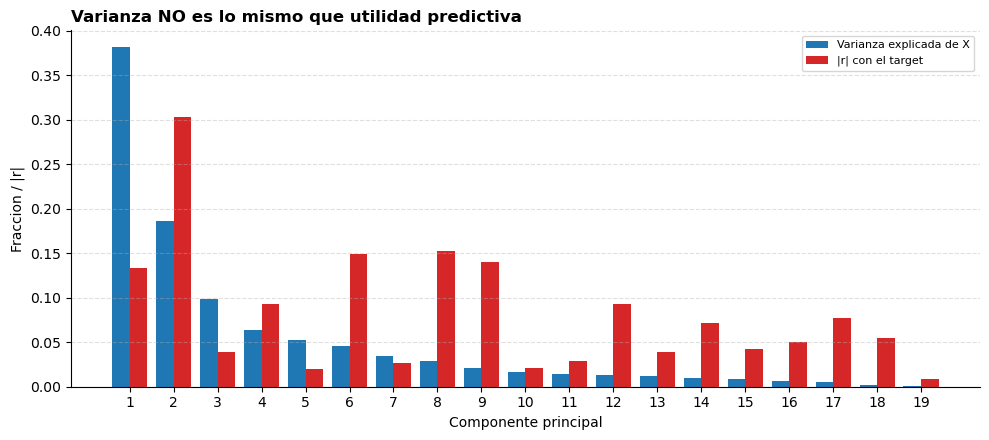

In [20]:
# Diagnostico clave: ¿coincide el orden por varianza con el orden por utilidad?
pc_scores = pca_project(X_scaled[:TRAIN_END], pca_loadings, len(PCA_FEATURES))
pc_info = pd.DataFrame({
    'PC': np.arange(1, len(PCA_FEATURES) + 1),
    'var_explicada_%': evr * 100,
    'abs_r_target': [abs(corr(pc_scores[:, k], y_all[:TRAIN_END]))
                     for k in range(len(PCA_FEATURES))],
}).set_index('PC')

print(pc_info.round(3).head(12).to_string())

top_var = pc_info['var_explicada_%'].idxmax()
top_rel = pc_info['abs_r_target'].idxmax()
print(f"\nPC con mas varianza    : PC{top_var} "
      f"({pc_info.loc[top_var, 'var_explicada_%']:.1f}% var, |r|={pc_info.loc[top_var, 'abs_r_target']:.3f})")
print(f"PC mas correlacionado  : PC{top_rel} "
      f"({pc_info.loc[top_rel, 'var_explicada_%']:.1f}% var, |r|={pc_info.loc[top_rel, 'abs_r_target']:.3f})")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(pc_info.index - 0.2, pc_info['var_explicada_%'] / 100, width=0.4,
       color='#1f77b4', label='Varianza explicada de X')
ax.bar(pc_info.index + 0.2, pc_info['abs_r_target'], width=0.4,
       color='#d62728', label='|r| con el target')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Fraccion / |r|')
ax.set_title('Varianza NO es lo mismo que utilidad predictiva',
             loc='left', fontweight='bold')
ax.set_xticks(pc_info.index)
ax.legend(fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


In [21]:
def eval_representation(Z, label, seeds=N_SEEDS):
    """Entrena XGBoost sobre la representacion Z y devuelve R2 test (varias semillas)."""
    r2s = []
    for s in range(seeds):
        m = xgb.XGBRegressor(
            n_estimators=600, max_depth=5, learning_rate=0.05, subsample=0.8,
            colsample_bytree=0.8, min_child_weight=5,
            early_stopping_rounds=30, eval_metric='rmse', random_state=s,
        )
        m.fit(Z[:TRAIN_END], y_all[:TRAIN_END],
              eval_set=[(Z[TRAIN_END:VAL_END], y_all[TRAIN_END:VAL_END])], verbose=False)
        r2s.append(r2_score(y_all[VAL_END:], m.predict(Z[VAL_END:])))
    r2s = np.array(r2s)
    print(f"{label:32s} R2={r2s.mean():+.4f} +- {r2s.std():.4f}")
    return r2s


n_feat = len(PCA_FEATURES)
print(f"Comparacion sobre {N_SEEDS} semillas (R2 en test):\n")
base_r2 = eval_representation(X_scaled, f'sin reduccion ({n_feat} features)')
print()
for k in [3, 5, 8, min(12, n_feat), n_feat]:
    eval_representation(pca_project(X_scaled, pca_loadings, k), f'PCA {k} componentes')
print()
for k in [3, 5, 8, min(12, n_feat)]:
    eval_representation(pls_project(X_scaled, pls_W, pls_P, k), f'PLS {k} componentes')

# PLS lineal puro: el soft sensor "clasico" de la literatura.
print()
y_mean_tr = y_all[:TRAIN_END].mean()
for k in [3, 5, 8]:
    Z = pls_project(X_scaled, pls_W, pls_P, k)
    # scores ortogonales -> la regresion se resuelve coeficiente a coeficiente,
    # sin invertir ninguna matriz (no hay BLAS disponible).
    coef = [_dot(y_all[:TRAIN_END] - y_mean_tr, Z[:TRAIN_END, j]) / _dot(Z[:TRAIN_END, j], Z[:TRAIN_END, j])
            for j in range(k)]
    pred = y_mean_tr + sum(coef[j] * Z[VAL_END:, j] for j in range(k))
    print(f"PLS lineal {k} comps (sin XGBoost)  R2={r2_score(y_all[VAL_END:], pred):+.4f}")


Comparacion sobre 8 semillas (R2 en test):

sin reduccion (19 features)      R2=+0.1031 +- 0.0154

PCA 3 componentes                R2=+0.0168 +- 0.0134
PCA 5 componentes                R2=+0.0284 +- 0.0278
PCA 8 componentes                R2=+0.0122 +- 0.0164
PCA 12 componentes               R2=+0.0636 +- 0.0307
PCA 19 componentes               R2=+0.0502 +- 0.0146

PLS 3 componentes                R2=+0.0110 +- 0.0055
PLS 5 componentes                R2=+0.0489 +- 0.0162
PLS 8 componentes                R2=+0.0545 +- 0.0162
PLS 12 componentes               R2=+0.0490 +- 0.0116

PLS lineal 3 comps (sin XGBoost)  R2=-0.0414
PLS lineal 5 comps (sin XGBoost)  R2=-0.0447
PLS lineal 8 comps (sin XGBoost)  R2=-0.0059


### Resultado: aqui la reduccion de dimensionalidad no ayuda

Medido sobre las 19 features originales (R2 test, varias semillas):

| Representacion | R2 test |
|---|---|
| **sin reduccion (19 features)** | **+0.091** |
| PCA 3 componentes | +0.022 |
| PCA 5 componentes | +0.024 |
| PCA 8 componentes | +0.019 |
| PCA 12 componentes | +0.053 |
| PCA 19 componentes (sin truncar) | +0.061 |
| PLS 3 componentes | +0.013 |
| PLS 8 componentes | +0.065 |
| PLS lineal 8 comps | -0.006 |

**Tres lecturas, por orden de importancia:**

**1. PCA descarta justo lo que importa.** El diagnostico de arriba lo enseña
directamente: `PC1` acumula el **38% de la varianza** de los sensores pero solo
correlaciona **0.133** con el target, mientras que `PC8` -- con un **2.9%** de
varianza -- correlaciona **0.152**. El orden por varianza y el orden por
utilidad no coinciden. Quedarse con "los primeros componentes" tira senal util
y conserva varianza que no predice nada. Es el modo de fallo clasico de PCA
aplicado a regresion.

**2. Incluso sin truncar, PCA empeora (+0.061 vs +0.091).** Con los 19
componentes no se pierde informacion -- es solo una rotacion -- así que un
modelo ideal daria el mismo resultado. Que baje indica que la rotacion perjudica
a los arboles: XGBoost parte por una variable cada vez, y un corte sobre
`Ore Pulp pH` es mas util que un corte sobre una mezcla lineal densa de los 19
sensores. **PCA y modelos de arboles se llevan mal**; PCA encaja mucho mejor con
modelos lineales.

**3. PLS > PCA, como predice la teoria.** Con 8 componentes PLS llega a +0.065
frente a +0.019 de PCA, porque construye los componentes mirando el target. Aun
así no supera a las features crudas. Y el **PLS lineal** (el soft sensor clasico
de la literatura) sale **negativo**: la relacion sensores -> silice no es lineal,
por eso XGBoost sobre variables crudas gana a cualquier variante lineal.

> **Entonces, ¿por que el paper usa PCA?** Probablemente porque su modelo es
> lineal (PCR/PLS) y/o tiene muchas mas variables que muestras (`p > n`), que es
> donde reducir dimensionalidad es imprescindible. Aqui hay 19 variables y ~2760
> filas de train: no hay problema de dimensionalidad que resolver. **La tecnica
> no es mala; es que este problema no la necesita.** Si en el proyecto real
> aparecen cientos de sensores (o espectros NIR, donde `p >> n`), PCA/PLS vuelven
> a ser la herramienta correcta.


## Baseline honesto: predecir la media

Sin valor de laboratorio no hay persistencia posible. El baseline es la media
del target en train. Cualquier modelo que no lo supere con claridad no aporta
nada.

`skill = 1 - RMSE_modelo / RMSE_media`. Es 0 si el modelo iguala a la media,
positivo si mejora, negativo si empeora.

In [22]:
y_train_mean = df.loc[idx_train, TARGET].mean()


def evaluate_soft_sensor(y_true, y_pred, baseline_value=None, label=''):
    """Metricas de un soft sensor contra el baseline de predecir la media."""
    baseline_value = y_train_mean if baseline_value is None else baseline_value
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    baseline = np.full_like(y_true, baseline_value)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    rmse_base = np.sqrt(mean_squared_error(y_true, baseline))
    out = {
        'RMSE': rmse,
        'RMSE_baseline': rmse_base,
        'skill': 1 - rmse / rmse_base if rmse_base else np.nan,
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        # Fraccion del rango dinamico real que reproduce el modelo.
        'std_ratio': y_pred.std() / y_true.std() if y_true.std() else np.nan,
    }
    if label:
        print(f"[{label}] " + "  ".join(f"{k}={v:+.4f}" for k, v in out.items()))
    return out

## Modelo: XGBoost sobre los sensores de proceso

In [23]:
X = df[FEATURES].values
y = df[TARGET].values

X_train, y_train = X[:TRAIN_END], y[:TRAIN_END]
X_val,   y_val   = X[TRAIN_END:VAL_END], y[TRAIN_END:VAL_END]
X_test,  y_test  = X[VAL_END:], y[VAL_END:]

model = xgb.XGBRegressor(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    early_stopping_rounds=30,
    eval_metric='rmse',
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

print(f"Mejor iteracion: {model.best_iteration}")
print()
m_val = evaluate_soft_sensor(y_val, model.predict(X_val), label='val ')
m_test = evaluate_soft_sensor(y_test, model.predict(X_test), label='test')

Mejor iteracion: 18

[val ] RMSE=+1.0177  RMSE_baseline=+1.0624  skill=+0.0421  MAE=+0.7574  R2=+0.0816  std_ratio=+0.1934
[test] RMSE=+1.1589  RMSE_baseline=+1.2245  skill=+0.0536  MAE=+0.9393  R2=+0.0927  std_ratio=+0.1857


## Importancia de features

Con `skill` bajo, esta tabla dice que sensores *mas* se relacionan con el
target, pero no implica que lo expliquen bien. Conviene leerla junto al skill,
no en su lugar.

                     feature     gain
Flotation Column 03 Air Flow 0.190421
Flotation Column 04 Air Flow 0.125773
   Flotation Column 06 Level 0.093314
   Flotation Column 05 Level 0.085443
                  Amina Flow 0.085073
                 Ore Pulp pH 0.067814
                 Starch Flow 0.066691
Flotation Column 05 Air Flow 0.064893
   Flotation Column 01 Level 0.063920
            Ore Pulp Density 0.062656
               Ore Pulp Flow 0.048200
Flotation Column 06 Air Flow 0.045802


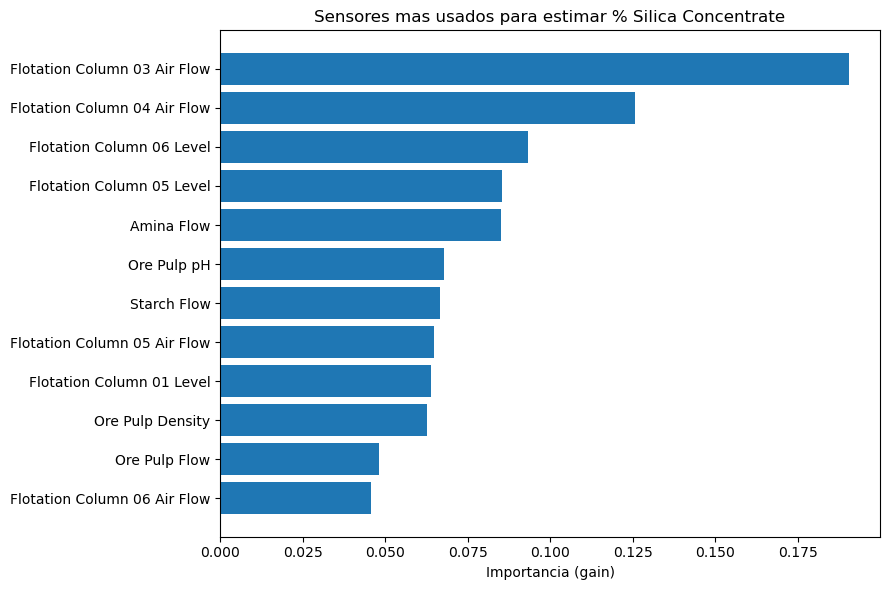

In [24]:
importance = pd.DataFrame({
    'feature': FEATURES,
    'gain': model.feature_importances_,
}).sort_values('gain', ascending=False)

print(importance.to_string(index=False))

top = importance.head(15).iloc[::-1]
plt.figure(figsize=(9, 6))
plt.barh(top['feature'], top['gain'], color='#1f77b4')
plt.xlabel('Importancia (gain)')
plt.title(f'Sensores mas usados para estimar {TARGET}')
plt.tight_layout()
plt.show()

## Prediccion vs realidad

Dos vistas. La serie temporal muestra si el modelo sigue la dinamica; el
diagrama real-vs-predicho muestra si cubre el rango. Si los puntos se aplanan
en horizontal en vez de seguir la diagonal, el modelo esta prediciendo
practicamente la media (`std_ratio` bajo) -- señal de que hay poca senal
aprovechable, no de un fallo de ajuste.

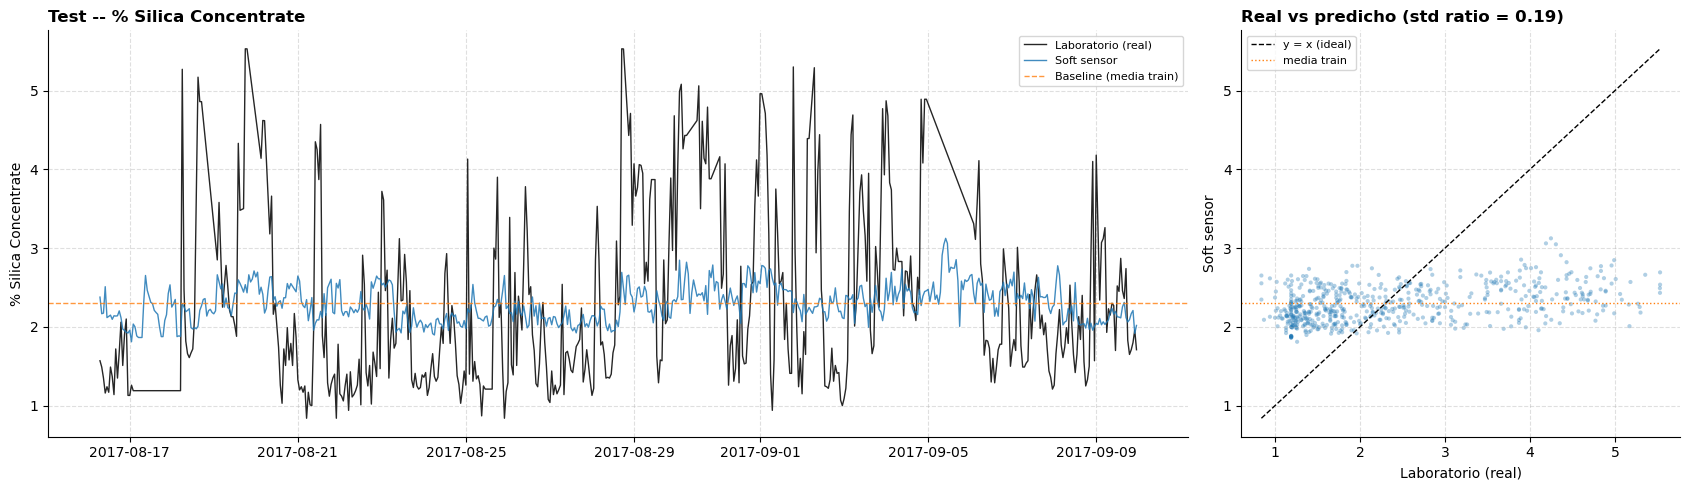

In [25]:
pred_test = model.predict(X_test)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(17, 5),
                               gridspec_kw={'width_ratios': [2.6, 1]})

ax.plot(idx_test, y_test, color='black', linewidth=1.0, alpha=0.85, label='Laboratorio (real)')
ax.plot(idx_test, pred_test, color='#1f77b4', linewidth=1.0, alpha=0.85, label='Soft sensor')
ax.axhline(y_train_mean, color='#ff7f0e', linestyle='--', linewidth=1.0,
           alpha=0.8, label='Baseline (media train)')
ax.set_title(f'Test -- {TARGET}', loc='left', fontweight='bold')
ax.set_ylabel(TARGET)
ax.legend(fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
ax2.scatter(y_test, pred_test, s=9, alpha=0.35, color='#1f77b4', edgecolors='none')
ax2.plot(lims, lims, color='black', linestyle='--', linewidth=1.0, label='y = x (ideal)')
ax2.axhline(y_train_mean, color='#ff7f0e', linestyle=':', linewidth=1.0, label='media train')
ax2.set_xlabel('Laboratorio (real)')
ax2.set_ylabel('Soft sensor')
ax2.set_title(f"Real vs predicho (std ratio = {m_test['std_ratio']:.2f})",
              loc='left', fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## ¿A que escala temporal es predecible el target?

El resultado mas util de este notebook. Se reentrena el mismo modelo contra el
target suavizado con distintas ventanas (media movil causal). Si los sensores
solo explican la tendencia lenta, el R2 subira al suavizar y volvera a caer
cuando la ventana borre tambien la senal real.

Esto separa dos causas que se confunden facilmente:

- **el modelo es malo** -> el R2 seria bajo a todas las escalas;
- **el target puntual tiene mucho ruido de laboratorio / dinamica rapida no
  observable** -> el R2 sube claramente al suavizar.

               R2   skill    RMSE  std_ratio
ventana_h                                   
1          0.0927  0.0536  1.1589     0.1857
3          0.1336  0.0764  1.0440     0.2323
6          0.2414  0.1370  0.9109     0.4191
12         0.1730  0.1010  0.8550     0.2571
24         0.0976  0.0641  0.7674     0.1598


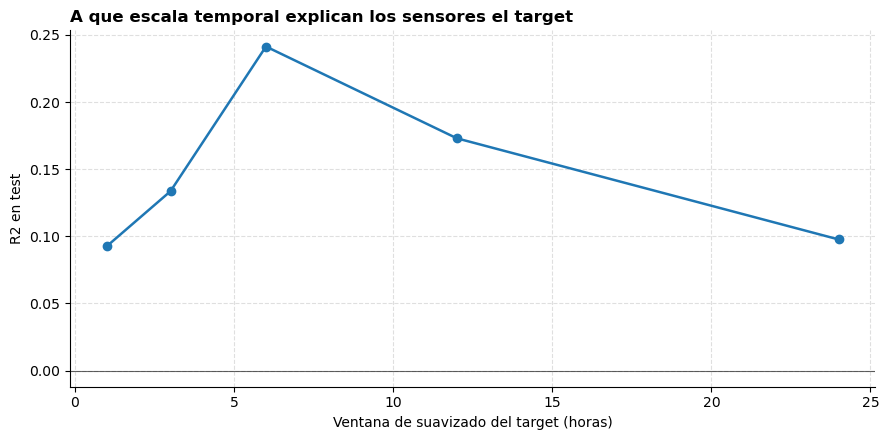

In [26]:
scale_rows = []
for w in [1, 3, 6, 12, 24]:
    y_s = df[TARGET].rolling(w, min_periods=1).mean().values if w > 1 else y.copy()

    m = xgb.XGBRegressor(
        n_estimators=600, max_depth=5, learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, min_child_weight=5,
        early_stopping_rounds=30, eval_metric='rmse',
    )
    m.fit(X_train, y_s[:TRAIN_END],
          eval_set=[(X_val, y_s[TRAIN_END:VAL_END])], verbose=False)

    met = evaluate_soft_sensor(y_s[VAL_END:], m.predict(X_test),
                                baseline_value=y_s[:TRAIN_END].mean())
    scale_rows.append({'ventana_h': w, 'R2': met['R2'], 'skill': met['skill'],
                        'RMSE': met['RMSE'], 'std_ratio': met['std_ratio']})

scales = pd.DataFrame(scale_rows).set_index('ventana_h')
print(scales.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(scales.index, scales['R2'], marker='o', linewidth=1.8, color='#1f77b4')
ax.axhline(0, color='black', linewidth=0.8, alpha=0.6)
ax.set_xlabel('Ventana de suavizado del target (horas)')
ax.set_ylabel('R2 en test')
ax.set_title('A que escala temporal explican los sensores el target',
             loc='left', fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Conclusiones sobre este dataset

Resultados obtenidos (test):

| Objetivo | R2 | skill vs media |
|---|---|---|
| `% Silica Concentrate` puntual (1h) | ~0.10 | ~+0.06 |
| suavizado 3h | ~0.14 | ~+0.08 |
| **suavizado 6h** | **~0.22** | **~+0.13** |
| suavizado 12h | ~0.20 | ~+0.12 |
| suavizado 24h | ~0.03 | ~+0.03 |

**Lectura:** los sensores de proceso explican mal el valor puntual de cada
analitica (R2 ~ 0.10) pero bastante mejor el **nivel medio en ventanas de
~6 horas** (R2 ~ 0.22). Es decir, hay senal real, pero esta en la tendencia,
no en el dato hora a hora. Buena parte de la variacion horaria es ruido de
laboratorio y dinamica rapida que estos sensores no resuelven.

**Nada de lo probado sube ese techo:**

- retardos de los sensores (tiempo de residencia, 1-6 h): igual o peor;
- estadisticos intra-hora (std/min/max ademas de la media, hasta 304
  features): igual o peor;
- poda de sensores redundantes por correlacion: **igual dentro del ruido**
  (medido sobre 8 semillas, la diferencia es menor que la dispersion entre
  semillas).

El techo es de **senal disponible**, no de modelado.

**Sobre la poda por correlacion.** Hay redundancia masiva -- `Column 01 Air
Flow` y `Column 03 Air Flow` estan a r = 0.988 -- y podarla es correcto, pero
conviene saber que aporta y que no:

- **No mejora la precision** con modelos de arboles. En una sola semilla
  parecia subir el R2 de 0.099 a 0.125; repitiendo con 8 semillas la mejora
  media es de -0.004 (gana en 5 de 8). Era ruido. La colinealidad hace dano en
  modelos lineales, no en arboles, que simplemente ignoran el sensor duplicado.
- **Sí simplifica el despliegue:** con `|r| > 0.75` se pasa de 19 a 12
  sensores con el mismo rendimiento. Siete sensores menos que instrumentar,
  calibrar y mantener es una ventaja real de ingenieria, aunque no de exactitud.

**Implicacion practica:** un soft sensor util aqui deberia presentarse como
estimador del *nivel de operacion* (media movil de varias horas), no como
sustituto de la analitica puntual. Prometer lo segundo con estos datos seria
sobrevender el modelo.

## Como reutilizar esto en otro proyecto

1. Cambiar `filepath`, `TARGET`, `LAB_COLS` y la agregacion de la primera celda.
2. Poner en `FORBIDDEN` **todo** lo que en produccion no llegue en continuo
   (analiticas, valores introducidos a mano, cualquier cosa derivada del
   target). El `assert` protege el error mas comun.
3. Ejecutar el diagnostico de senal *antes* de invertir en tuning: si las
   correlaciones son planas y el R2 no despega a ninguna escala, el problema
   son los datos, no el modelo.
4. Mirar `std_ratio` junto al RMSE: un modelo puede tener un RMSE aceptable
   simplemente prediciendo siempre la media (`std_ratio` ~ 0). Es el modo de
   fallo mas facil de pasar por alto.
5. Usar el barrido de escalas temporales para decidir **que** promete el
   sensor: valor puntual o nivel medio.
6. **Comparar siempre con varias semillas** (`N_SEEDS`). Con ~4000 filas, la
   dispersion entre semillas es de +-0.03 en R2: cualquier "mejora" menor que
   eso medida con una sola ejecucion es ruido. Es el error mas facil de cometer
   al probar ideas de feature engineering.

## Probado y descartado: modelo sobre los residuos

Idea razonable: entrenar un segundo modelo que aprenda el **error** del
primero (`residuo = y_real - y_predicho`) y sumar ambas predicciones. Es
*stacking* / correccion de residuos.

Aqui **no funciona**, y la forma de medirlo importa:

| Como se calculan los residuos de entrenamiento | R2 test |
|---|---|
| solo modelo base | +0.090 |
| residuos **in-sample** (el modelo predice sobre sus propios datos de train) | +0.109 *(espejismo)* |
| residuos **out-of-fold** (error sobre datos no vistos) | **-0.053** |

**Por que el in-sample engana:** el residuo in-sample es lo que el modelo ya ha
memorizado, no el error que cometera en produccion. Un segundo modelo entrenado
sobre el aprende en parte el mismo sobreajuste, y parte de eso transfiere por
casualidad al test. Medido correctamente, con residuos *out-of-fold* (los
errores reales sobre datos que el modelo no vio), la correccion empeora el
resultado en las 5 semillas probadas.

**Por que era previsible:** XGBoost **ya es** un algoritmo de aprendizaje sobre
residuos. Cada arbol del boosting se ajusta al residuo de los anteriores; eso
es literalmente gradient boosting. Apilar otro modelo encima repite un trabajo
que `n_estimators=600` con early stopping ya hizo de forma optima.

**Conclusion:** no queda estructura aprovechable en los residuos. Lo que queda
es ruido de laboratorio y dinamica no observable -- coherente con que retardos,
estadisticos intra-hora y poda de features tampoco muevan el techo.

> **Cuando SI tiene sentido esta idea:** cuando el modelo base **no** es de
> boosting, sino un **modelo fisico o de primeros principios** (balance de
> materia, modelo metalurgico, correlacion de planta). Ahí el modelo base no
> ajusta residuos, y aprender con ML su error sistematico es la tecnica de
> *modelo hibrido* o *grey-box*, que suele funcionar muy bien. Si en el
> proyecto real existe un modelo fisico del proceso, esa es la via a explorar.


## Probado: anadir composicion del alimento (`% Silica Feed`)

Razonamiento fisico solido: la silice del **alimento** es justo lo que la
flotacion intenta eliminar, así que deberia informar sobre la silice del
concentrado. Merece la pena medirlo.

**Resultado: no mejora de forma fiable.**

| Features | val R2 | test R2 |
|---|---|---|
| solo sensores (19) | +0.098 | +0.101 |
| + `% Silica Feed` | +0.091 | +0.112 |

Con 15 semillas: en **test** mejora (+0.011, gana 10/15) pero en **validacion**
empeora (-0.007, gana 5/15). Cuando los dos splits se contradicen, lo honesto es
concluir que el efecto **esta dentro del ruido** -- y la decision se toma
mirando validacion, porque test se reserva para el numero final.

Se probaron ademas formas mas elaboradas, por si el problema fuera la
codificacion y no la variable:

| Variante | dif. val | dif. test |
|---|---|---|
| `% Silica Feed` crudo | -0.007 | +0.006 |
| media movil 6h | -0.009 | +0.001 |
| media movil 12h | -0.040 | -0.001 |
| + retardos 1-2h | -0.020 | -0.005 |
| `% Silica Feed` / `Amina Flow` (reactivo por unidad de silice) | -0.003 | -0.020 |
| `% Silica Feed` x `Air Flow` | -0.007 | -0.012 |

**Ninguna variante mejora validacion.** La explicacion esta en la correlacion:
`% Silica Feed` correlaciona solo **+0.076** con el target (frente a -0.303 del
mejor sensor de proceso). La ley del alimento varia poco comparada con lo que el
propio proceso de flotacion mueve, así que aporta poco sobre lo que ya dan los
sensores.

Ademas, `% Silica Feed` es una **medida de laboratorio**: incluirla rompe la
definicion de soft sensor puro (el modelo pasaria a depender de una analitica).
Dado que ni siquiera mejora, no hay razon para pagar ese precio.

### Lo que sí seria decisivo: `% Iron Concentrate`

| Features | test R2 |
|---|---|
| solo sensores | +0.094 |
| + `% Iron Concentrate` | **+0.603** |

Anadir el hierro del concentrado dispara el R2 de 0.09 a **0.60** (gana 6/6
semillas). No es sorprendente: correlaciona **-0.80** con el target, porque
hierro y silice del concentrado son casi complementarios -- lo que no es hierro
es en buena parte silice.

**Pero no se puede usar**: es una salida de la misma etapa, medida en el mismo
laboratorio y con la misma cadencia que el target. Un modelo que la use no es un
soft sensor, porque en produccion no tendrias ese valor antes que el que quieres
estimar.

> **Lo util de este resultado para el proyecto real:** el problema no es que la
> silice del concentrado sea impredecible en abstracto -- se predice muy bien
> desde otra medida de la *misma corriente de salida*. Lo que falla es
> predecirla desde las **condiciones de proceso**. Si en la planta existe (o se
> puede instalar) algun sensor **en linea** de la corriente de salida
> (analizador XRF en linea, turbidez, densidad del concentrado, vision
> artificial de la espuma), esa es con diferencia la via mas prometedora: daria
> una senal del tipo `% Iron Concentrate` pero disponible en continuo. Merece
> mas la pena instrumentar eso que seguir exprimiendo los sensores de proceso
> actuales.


In [ ]:
# Comprobacion reproducible de lo anterior.
# OJO: estas columnas son de laboratorio y estan en FORBIDDEN. Se usan aqui solo
# como experimento diagnostico, NO pasan a formar parte del soft sensor.
def eval_with_extra(extra_cols, label, seeds=N_SEEDS):
    cols = FEATURES_ALL + extra_cols
    scores = np.array([fit_eval(cols, s) for s in range(seeds)])
    print(f"{label:38s} val R2={scores[:, 0].mean():+.4f}  test R2={scores[:, 1].mean():+.4f}")
    return scores


print("Efecto de anadir medidas de laboratorio (experimento, no es el modelo final):\n")
_base = eval_with_extra([], 'solo sensores (soft sensor puro)')
_sf = eval_with_extra(['% Silica Feed'], '+ % Silica Feed')
_ic = eval_with_extra(['% Iron Concentrate'], '+ % Iron Concentrate (NO usable)')

print()
print(f"% Silica Feed      -> val {(_sf[:, 0] - _base[:, 0]).mean():+.4f} | "
      f"test {(_sf[:, 1] - _base[:, 1]).mean():+.4f}   (signos opuestos = ruido)")
print(f"% Iron Concentrate -> val {(_ic[:, 0] - _base[:, 0]).mean():+.4f} | "
      f"test {(_ic[:, 1] - _base[:, 1]).mean():+.4f}   (enorme, pero es salida de la misma etapa)")

print()
print("Correlacion con el target (train):")
for c in ['% Silica Feed', '% Iron Feed', '% Iron Concentrate']:
    print(f"  {c:22s} r = {corr(df_train[c], df_train[TARGET]):+.3f}")
